Student Retention and Attrition Predictive Analysis

### Business Problem ###
Educational institutions struggle to identify at-risk students before they drop out, leading to lost tuition revenue and diminished student success metrics. This project aims to build a predictive model that uses student engagement data measured quarterly (Q1-Q3) and demographic information to identify students at risk of attrition, enabling the Student Success Team to deploy targeted interventions during the final term to improve success rates.
*Note: Synthetic data was created using Gemini for this analysis

### Success Metric ###
Primary Metric: Recall (Sensitivity)

Because the "cost" of a False Negative (failing to identify a student who eventually drops out) is significantly higher than the cost of a False Positive (checking in on a student who is performing fine), this project prioritizes Recall.

Target: Achieve a Recall score of >0.85 for the "Dropped Out" class.

Justification: Low-cost automated interventions (GenAI-powered check-ins, automated resource sharing) allow the Student Success Team to cast a wider net. Our goal is to identify students at risk of attrition, including 'digital ghosts' - students with no LMS login activity in Q1-Q3. This allows for a more nuanced analysis of how different engagement profiles relate to graduation outcomes.

Secondary Metric: F1-Score

While Recall is the priority, we will monitor the F1-Score to ensure the model maintains a functional balance and does not flag every student as "at-risk," which would lead to "alert fatigue" for the intervention team.

#### Environment Setup & Data Ingestion ####

In [1]:
# Import libraries
# ==========================================
# Standard Library & File System
# ==========================================
from pathlib import Path
import math
from scipy import stats

# ==========================================
# Jupyter Notebook / Display
# ==========================================
from IPython.display import display

# ==========================================
# Data Manipulation
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# Visualization
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Project root (set cwd to the project folder in your IDE, or override project_dir here)
project_dir = Path.cwd()
data_dir = project_dir / "data"
data_dir.mkdir(parents=True, exist_ok=True)
print("Working directory:", project_dir)
print("Data directory:", data_dir)

registry_path = data_dir / "student_registry.csv"
engagement_path = data_dir / "engagement_data.csv"

if not registry_path.exists() or not engagement_path.exists():
    raise FileNotFoundError(
        "Could not find one or both CSV files. Expected:\n"
        f"- {registry_path}\n"
        f"- {engagement_path}\n\n"
        "Tip: Put the CSVs in the project `data` folder, or set project_dir to the folder that contains `data/`."
    )

# Load datasets
df_registry = pd.read_csv(registry_path)
df_engagement = pd.read_csv(engagement_path)

# Raw datset copies
df_raw_registry = df_registry.copy()
df_raw_engagement = df_engagement.copy()

# Persist raw copies alongside the source CSVs
raw_registry_path = data_dir / "student_registry_raw.csv"
raw_engagement_path = data_dir / "engagement_data_raw.csv"
df_raw_registry.to_csv(raw_registry_path, index=False)
df_raw_engagement.to_csv(raw_engagement_path, index=False)
print(f"Saved raw snapshots:\n  {raw_registry_path}\n  {raw_engagement_path}")


Working directory: c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor
Data directory: c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor\data
Saved raw snapshots:
  c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor\data\student_registry_raw.csv
  c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor\data\engagement_data_raw.csv


#### Initial Data Exploration ####

In [2]:
# Inspect datasets
print("\nRegistry head:")
display(df_registry.head())
print("\nRegistry info:")
df_registry.info()

print("\nEngagement head:")
display(df_engagement.head())
print("\nEngagement info:")
df_engagement.info()

print("\nRegistry missing values:")
display(df_registry.isna().sum())
print("\nEngagement missing values:")
display(df_engagement.isna().sum())


# Unique values for string columns
print("\nUnique values for string columns:")
for col in ["major", "gender", "financial_aid", "tuition_status"]:
    if col in df_registry.columns:
        print(f"\n{col} — unique values:")
        print(sorted(df_registry[col].dropna().unique(), key=str))
        if df_registry[col].isna().any():
            print("  (+ missing values / NaN also present)")

if "quarter" in df_engagement.columns:
    print("\nquarter — unique values:")
    print(sorted(df_engagement["quarter"].dropna().unique(), key=str))
    if df_engagement["quarter"].isna().any():
        print("  (+ missing values / NaN also present)")


Registry head:


,student_id,major,age,gender,prior_gpa,credits_failed_pct,financial_aid,tuition_status,graduated
0,64759,Computer Science,31,Female,2.41,0.182085,Private Scholarship,Paid,1
1,22456,CompSci,24,Female,2.46,0.546855,Federal Grant,Paid,0
2,63401,CompSci,21,Male,3.62,0.020966,No Aid,Paid,1
3,72903,Computer Science,19,Female,3.22,0.071668,Private Scholarship,Paid,1
4,76338,Arts,22,Male,2.14,0.177144,No Aid,Deferred,1



Registry info:
<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          7500 non-null   int64  
 1   major               7500 non-null   str    
 2   age                 7500 non-null   int64  
 3   gender              7500 non-null   str    
 4   prior_gpa           7500 non-null   float64
 5   credits_failed_pct  7500 non-null   float64
 6   financial_aid       7400 non-null   str    
 7   tuition_status      7500 non-null   str    
 8   graduated           7500 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 527.5 KB

Engagement head:


,student_id,quarter,time_on_materials_min,logins,forum_posts
0,64759,Q1,186,7,2
1,64759,Q2,237,9,1
2,64759,Q3,84,4,1
3,22456,Q1,243,11,2
4,22456,Q2,169,7,3



Engagement info:
<class 'pandas.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student_id             21600 non-null  int64
 1   quarter                21600 non-null  str  
 2   time_on_materials_min  21600 non-null  int64
 3   logins                 21600 non-null  int64
 4   forum_posts            21600 non-null  int64
dtypes: int64(4), str(1)
memory usage: 843.9 KB

Registry missing values:


student_id              0
major                   0
age                     0
gender                  0
prior_gpa               0
credits_failed_pct      0
financial_aid         100
tuition_status          0
graduated               0
dtype: int64


Engagement missing values:


student_id               0
quarter                  0
time_on_materials_min    0
logins                   0
forum_posts              0
dtype: int64


Unique values for string columns:

major — unique values:
['Arts', 'Business', 'CS', 'CompSci', 'Computer Science', 'Mathematics']

gender — unique values:
['Female', 'Male', 'Non-binary', 'Prefer not to say']

financial_aid — unique values:
['Federal Grant', 'No Aid', 'Private Scholarship', 'Student Loan']
  (+ missing values / NaN also present)

tuition_status — unique values:
['Deferred', 'Delinquent', 'Paid']

quarter — unique values:
['Q1', 'Q2', 'Q3']


In [3]:
# Investigate dataset summary statistics
print("\nRegistry Summary Statistics:")
display(df_registry.describe(include='all'))
print("\nEngagement Summary Statistics:")
display(df_engagement.describe(include='all'))

# Return percentage of each class in the target variable
print(df_registry['graduated'].value_counts(normalize=True))


Registry Summary Statistics:


,student_id,major,age,gender,prior_gpa,credits_failed_pct,financial_aid,tuition_status,graduated
count,7500.000000,7500,7500.000000,7500,7500.000000,7500.000000,7400,7500,7500.000000
unique,NaN,6,NaN,4,NaN,NaN,4,3,NaN
top,NaN,Computer Science,NaN,Female,NaN,NaN,No Aid,Paid,NaN
freq,NaN,1283,NaN,3653,NaN,NaN,1881,5239,NaN
mean,54524.199867,NaN,23.077733,NaN,3.012947,0.168448,NaN,NaN,0.851333
std,25832.102136,NaN,5.220101,NaN,0.610933,0.143392,NaN,NaN,0.355783
min,10103.000000,NaN,-1.000000,NaN,2.000000,0.000005,NaN,NaN,0.000000
25%,32165.750000,NaN,20.000000,NaN,2.500000,0.055461,NaN,NaN,1.000000
50%,54493.500000,NaN,22.000000,NaN,2.990000,0.131533,NaN,NaN,1.000000
75%,76975.500000,NaN,24.000000,NaN,3.510000,0.243578,NaN,NaN,1.000000



Engagement Summary Statistics:


,student_id,quarter,time_on_materials_min,logins,forum_posts
count,21600.000000,21600,21600.000000,21600.000000,21600.000000
unique,NaN,3,NaN,NaN,NaN
top,NaN,Q1,NaN,NaN,NaN
freq,NaN,7200,NaN,NaN,NaN
mean,54557.074722,NaN,148.991528,6.578472,1.503333
std,25809.665560,NaN,57.894341,3.171218,1.360379
min,10103.000000,NaN,30.000000,1.000000,0.000000
25%,32212.750000,NaN,99.000000,4.000000,0.000000
50%,54627.500000,NaN,148.000000,6.000000,1.000000
75%,76965.500000,NaN,200.000000,9.000000,2.000000


graduated
1    0.851333
0    0.148667
Name: proportion, dtype: float64


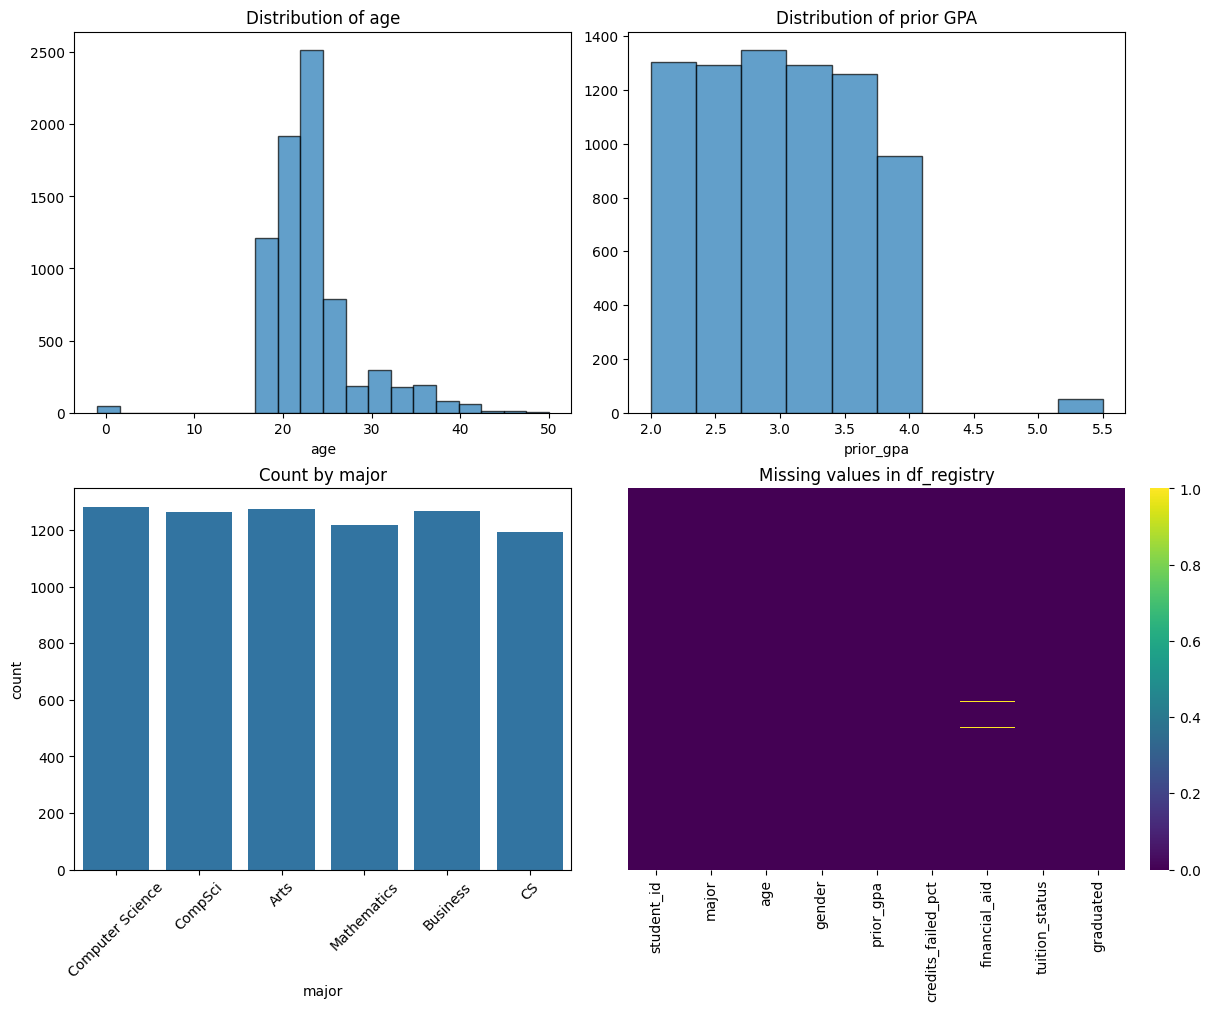

In [4]:
# visualize categories, outliers, and missing data
# draw plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
# age histogram
axes[0, 0].hist(df_registry["age"], bins=20, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of age")
axes[0, 0].set_xlabel("age")
# prior gpa histogram
axes[0, 1].hist(df_registry["prior_gpa"], edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Distribution of prior GPA")
axes[0, 1].set_xlabel("prior_gpa")
# plot majors and their counts
sns.countplot(data=df_registry, x="major", ax=axes[1, 0])
axes[1, 0].set_title("Count by major")
axes[1, 0].set_xlabel("major")
axes[1, 0].tick_params(axis="x", rotation=45)
# heatmap to show all missing data
sns.heatmap(
    df_registry.isnull(),
    ax=axes[1, 1],
    cbar=True,
    cmap="viridis",
    yticklabels=False,
)
axes[1, 1].set_title("Missing values in df_registry")

plt.show()


#### Univariate EDA Findings ####
Age: Found negative values (min: -1), indicating placeholder or entry errors.

GPA: Found values exceeding 4.0 (max: 5.5), suggesting a different scale was used or data is corrupted.

Major: Higher than expected unique count (6) due to naming inconsistencies (e.g., "CS" vs "Computer Science").

Financial Aid: column has missing values.

Student ID: datatype should be string

Engagement dataframe does not have 3x records of registry df, indicating 'ghost students', min logins column is 1, indicating students who have zero logins are not listed in the engagement dataframe

#### Structural Cleaning ####

In [5]:
# Convert student id to string 
df_registry['student_id'] = df_registry['student_id'].astype(str)
df_engagement['student_id'] = df_engagement['student_id'].astype(str)
# Validate
df_engagement.info()

<class 'pandas.DataFrame'>
RangeIndex: 21600 entries, 0 to 21599
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student_id             21600 non-null  str  
 1   quarter                21600 non-null  str  
 2   time_on_materials_min  21600 non-null  int64
 3   logins                 21600 non-null  int64
 4   forum_posts            21600 non-null  int64
dtypes: int64(3), str(2)
memory usage: 843.9 KB


#### Content Cleaning ####

In [6]:
# Pre-processing- inconsistent category names
# consolidate computer science major variants into single category

# Detect variants
print("Raw 'major' counts (Identified naming variants):")
display(df_registry["major"].value_counts())

# clean variants
_major_lower = df_registry["major"].str.strip().str.lower()
cs_variants = {"cs", "compsci", "computer science"}

# Declare variable to capture the count before transformation
needs_fixing = _major_lower.isin(cs_variants) & (df_registry["major"] != "Computer Science")
inconsistent_major_count = needs_fixing.sum()
print(f"Total inconsistent variants detected: {inconsistent_major_count}")


Raw 'major' counts (Identified naming variants):


major
Computer Science    1283
Arts                1274
Business            1269
CompSci             1265
Mathematics         1217
CS                  1192
Name: count, dtype: int64

Total inconsistent variants detected: 2457


In [7]:
# Transform

# Consolidate "major" variants to "Computer Science"
df_registry.loc[needs_fixing, "major"] = "Computer Science"

In [8]:
# Validate changes
print("\nCleaned 'major' counts (All variants merged):")
display(df_registry["major"].value_counts())


Cleaned 'major' counts (All variants merged):


major
Computer Science    3740
Arts                1274
Business            1269
Mathematics         1217
Name: count, dtype: int64

Result: Computer Science variants were consoliated into one category: "Computer Science".

In [30]:
# Pre-processing- handling sentinels
# Identify age sentinel values

# Detect sentinels
print("Raw 'age' distribution (Checking for -1 placeholders):")
display(df_registry["age"].describe())

# Identify rows where the age is the sentinel value -1
is_sentinel = (df_registry["age"] == -1)

# capture the count before transformation
missing_ages_count = is_sentinel.sum()
print(f"Total sentinel values (-1) detected: {missing_ages_count}")


Raw 'age' distribution (Checking for -1 placeholders):


count    7400.000000
mean       23.217432
std         4.821214
min        17.000000
25%        20.000000
50%        22.000000
75%        24.000000
max        50.000000
Name: age, dtype: float64

Total sentinel values (-1) detected: 0


In [10]:
# Transform 
# Nullify the sentinel values
df_registry.loc[is_sentinel, "age"] = np.nan

# Investigate distribution of "major" for sentinels to rule out systematic error
missing_ages_count = df_registry["age"].isnull().sum()
print(f"Total missing age records to be imputed: {missing_ages_count}")
print("Distribution of missing ages by Major (Systematic Error Check):")
display(df_registry[df_registry["age"].isnull()]["major"].value_counts())

# Impute with the median age of each student's specific Major
df_registry["age"] = df_registry["age"].fillna(
    df_registry.groupby("major")["age"].transform("median")
)


Total missing age records to be imputed: 50
Distribution of missing ages by Major (Systematic Error Check):


major
Computer Science    22
Mathematics         13
Arts                 9
Business             6
Name: count, dtype: int64

In [11]:
# Validate changes
print("\nCleaned 'age' distribution (Sentinels handled via grouped imputation):")
display(df_registry["age"].describe())
print(f"Remaining nulls in Age: {df_registry['age'].isnull().sum()}")


Cleaned 'age' distribution (Sentinels handled via grouped imputation):


count    7500.000000
mean       23.231067
std         4.834073
min        17.000000
25%        20.000000
50%        22.000000
75%        24.000000
max        50.000000
Name: age, dtype: float64

Remaining nulls in Age: 0


Result: Fifty instances of placeholder ages (-1) were found. Upon investigation, these were distributed across all majors, suggesting a random logging error rather than a department-specific issue. Grouped medians were imputed to maintain demographic integrity.

In [12]:
# Pre-processing- handling boundary violations
# Insuring all prior gpas fall in the allowable range

# Detect GPA values > 4.0
print("Raw 'prior_gpa' distribution (Checking for boundary violations):")
display(df_registry["prior_gpa"].describe())

# Identify rows where GPA is outside the valid 0.0 - 4.0 range
is_invalid_gpa = (df_registry["prior_gpa"] < 0.0) | (df_registry["prior_gpa"] > 4.0)

# Declare variable to capture the count before transformation
gpa_violation_count = is_invalid_gpa.sum()
print(f"Total GPA boundary violations detected: {gpa_violation_count}")

Raw 'prior_gpa' distribution (Checking for boundary violations):


count    7500.000000
mean        3.012947
std         0.610933
min         2.000000
25%         2.500000
50%         2.990000
75%         3.510000
max         5.500000
Name: prior_gpa, dtype: float64

Total GPA boundary violations detected: 50


In [13]:
# Transform

# Nullify the invalid GPA values
df_registry.loc[is_invalid_gpa, "prior_gpa"] = np.nan

# Investigate distribution of "major" for sentinels to rule out systematic error
invalid_gpa_count = df_registry["prior_gpa"].isnull().sum()
print(f"Total invalid GPAs to be imputed: {invalid_gpa_count}")
print("Distribution of invalid GPAs by Major (Systematic Error Check):")
display(df_registry[df_registry["prior_gpa"].isnull()]["major"].value_counts())

# Impute NaNs using the median GPA of each student's specific Major
df_registry["prior_gpa"] = df_registry["prior_gpa"].fillna(
    df_registry.groupby("major")["prior_gpa"].transform("median")
)

Total invalid GPAs to be imputed: 50
Distribution of invalid GPAs by Major (Systematic Error Check):


major
Computer Science    27
Business            13
Arts                 8
Mathematics          2
Name: count, dtype: int64

In [14]:
# Validate changes

print("\nCleaned 'prior_gpa' distribution (Violations handled via grouped imputation):")
display(df_registry["prior_gpa"].describe())
print(f"Remaining nulls in GPA: {df_registry['prior_gpa'].isnull().sum()}")


Cleaned 'prior_gpa' distribution (Violations handled via grouped imputation):


count    7500.000000
mean        2.996168
std         0.575954
min         2.000000
25%         2.500000
50%         2.990000
75%         3.490000
max         4.000000
Name: prior_gpa, dtype: float64

Remaining nulls in GPA: 0


Result: Fifty invalid prior_gpas were identified. Upon investigation, these were distributed across all majors, suggesting a random logging error rather than a department-specific issue. Grouped medians were imputed to maintain demographic integrity.

In [15]:
# Pre-processing- handling missing information

# Detect missing values
print("Raw 'financial_aid' distribution (Checking for missing values):")
display(df_registry["financial_aid"].value_counts(dropna=False))

# Identify rows where financial_aid is missing (NaN)
is_missing_aid = df_registry["financial_aid"].isnull()

# Declare variable to capture the count before transformation
missing_aid_count = is_missing_aid.sum()
print(f"Total missing Financial Aid records detected: {missing_aid_count}")

Raw 'financial_aid' distribution (Checking for missing values):


financial_aid
No Aid                 1881
Private Scholarship    1851
Federal Grant          1835
Student Loan           1833
NaN                     100
Name: count, dtype: int64

Total missing Financial Aid records detected: 100


In [16]:
# Transform

# Expose Systematic Error (Check if all missing aid data is from a singular major)
print("\nDistribution of missing Financial Aid by Major:")
display(df_registry[is_missing_aid]["major"].value_counts())

# Drop the corrupted records
# Overwrite the dataframe to permanently remove these 100 rows
df_registry = df_registry.dropna(subset=["financial_aid"])


Distribution of missing Financial Aid by Major:


major
Computer Science    52
Business            21
Arts                16
Mathematics         11
Name: count, dtype: int64

In [17]:
# Validate changes
print("\nCleaned 'financial_aid' categories (After dropping missing records):")
display(df_registry["financial_aid"].value_counts(dropna=False))

# Confirm the new shape of the dataset
print(f"Final record count after removal: {len(df_registry)}")
print(f"Remaining nulls in Financial Aid: {df_registry['financial_aid'].isnull().sum()}")


Cleaned 'financial_aid' categories (After dropping missing records):


financial_aid
No Aid                 1881
Private Scholarship    1851
Federal Grant          1835
Student Loan           1833
Name: count, dtype: int64

Final record count after removal: 7400
Remaining nulls in Financial Aid: 0


Result: To avoid introducing bias through mode imputation, the model will be built with a smaller, higher quality of clean records. These 100 records (1.3% of the total) have been dropped to ensure the integrity of the subsequent predictive modeling.

In [18]:
# Data Pre-processing summary table
audit_data = {
    "Feature": ["Major", "Age", "Prior GPA", "Financial Aid"],
    "Issue Detected": [
        "Inconsistent Naming Variants",
        "Sentinel Values (-1)",
        "Boundary Violations (<0 or >4)",
        "Missing/Null Records"
    ],
    "Cleaning Strategy": [
        "Direct Consolidation (Regex/Mapping)",
        "Grouped Median Imputation",
        "Grouped Median Imputation",
        "Record Removal (Dropping)"
    ],
    "Impact (Rows Affected)": [
        inconsistent_major_count,
        missing_ages_count,
        gpa_violation_count,
        missing_aid_count
    ]
}

# Create Audit DataFrame
df_audit = pd.DataFrame(audit_data)

# Display
print("--- FINAL DATA INTEGRITY AUDIT ---")
display(df_audit)

# Calculate total data retention for the write-up
retention_pct = (len(df_registry) / 7500) * 100
print(f"\nFinal Dataset Quality: {len(df_registry)} records retained ({retention_pct:.2f}%)")

--- FINAL DATA INTEGRITY AUDIT ---


,Feature,Issue Detected,Cleaning Strategy,Impact (Rows Affected)
0,Major,Inconsistent Naming Variants,Direct Consolidation (Regex/Mapping),2457
1,Age,Sentinel Values (-1),Grouped Median Imputation,50
2,Prior GPA,Boundary Violations (<0 or >4),Grouped Median Imputation,50
3,Financial Aid,Missing/Null Records,Record Removal (Dropping),100



Final Dataset Quality: 7400 records retained (98.67%)


In [19]:
# Pivot engagement table to consolidate 1 row/student
df_engagement_wide = df_engagement.pivot(
    index='student_id',
    columns='quarter',
    values=['logins', 'time_on_materials_min', 'forum_posts']
)

# Flatten multi-index columns (e.g., ('logins', 'q1') -> 'logins_q1')
df_engagement_wide.columns = [f'{metric}_{quarter}'.lower() for metric, quarter in df_engagement_wide.columns]
df_engagement_wide = df_engagement_wide.reset_index()

# Validate results
print(f"Engagement table now has {df_engagement_wide.shape[1]} columns.")
print(f"Original Engagement Rows: {len(df_engagement)}")
print(f"Pivoted (Wide) Rows: {len(df_engagement_wide)}")
print("\nEngagement_wide head:")
display(df_engagement_wide.head())

Engagement table now has 10 columns.
Original Engagement Rows: 21600
Pivoted (Wide) Rows: 7200

Engagement_wide head:


,student_id,logins_q1,logins_q2,logins_q3,time_on_materials_min_q1,time_on_materials_min_q2,time_on_materials_min_q3,forum_posts_q1,forum_posts_q2,forum_posts_q3
0,10103,11,5,3,196,165,82,0,0,2
1,10106,9,5,11,170,84,167,0,0,1
2,10124,11,2,11,189,67,195,1,0,2
3,10151,4,6,2,122,125,57,3,2,0
4,10221,6,3,4,157,76,102,3,1,1


Result: Granularity of data is now consistent with one student per row, however there are 300 more rows in the registry, indicating 300 "ghost" students who never logged into the LMS.

In [ ]:
# merge registry and engagement_wide dataframes using left join to preserve all students in registry
df_master = df_registry.merge(df_engagement_wide, on='student_id', how='left')

# Isolate the 9 new engagement columns
engagement_cols = [col for col in df_master.columns if '_q' in col]

# Replace NaN with 0 for "ghosts" in engagement columns
df_master[engagement_cols] = df_master[engagement_cols].fillna(0)

print(f"Final Master Table Shape: {df_master.shape}")
display(df_master.head())
display(df_master.info())

Final Master Table Shape: (7400, 18)


,student_id,major,age,gender,prior_gpa,credits_failed_pct,financial_aid,tuition_status,graduated,logins_q1,logins_q2,logins_q3,time_on_materials_min_q1,time_on_materials_min_q2,time_on_materials_min_q3,forum_posts_q1,forum_posts_q2,forum_posts_q3
0,64759,Computer Science,31.0,Female,2.41,0.182085,Private Scholarship,Paid,1,7.0,9.0,4.0,186.0,237.0,84.0,2.0,1.0,1.0
1,22456,Computer Science,24.0,Female,2.46,0.546855,Federal Grant,Paid,0,11.0,7.0,4.0,243.0,169.0,139.0,2.0,3.0,0.0
2,63401,Computer Science,21.0,Male,3.62,0.020966,No Aid,Paid,1,2.0,3.0,5.0,73.0,96.0,139.0,0.0,0.0,2.0
3,72903,Computer Science,19.0,Female,3.22,0.071668,Private Scholarship,Paid,1,8.0,8.0,7.0,205.0,215.0,215.0,2.0,3.0,2.0
4,76338,Arts,22.0,Male,2.14,0.177144,No Aid,Deferred,1,13.0,9.0,9.0,219.0,146.0,246.0,3.0,1.0,3.0


<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   student_id                7400 non-null   str    
 1   major                     7400 non-null   str    
 2   age                       7400 non-null   float64
 3   gender                    7400 non-null   str    
 4   prior_gpa                 7400 non-null   float64
 5   credits_failed_pct        7400 non-null   float64
 6   financial_aid             7400 non-null   str    
 7   tuition_status            7400 non-null   str    
 8   graduated                 7400 non-null   int64  
 9   logins_q1                 7400 non-null   float64
 10  logins_q2                 7400 non-null   float64
 11  logins_q3                 7400 non-null   float64
 12  time_on_materials_min_q1  7400 non-null   float64
 13  time_on_materials_min_q2  7400 non-null   float64
 14  time_on_materials_m

None

#### Feature Engineering ####

In [ ]:
# Add calculated columns and flags

# calculate change in logins from start (Q1) to the end (Q3)
df_master['login_velocity'] = df_master['logins_q3'] - df_master['logins_q1']

# calculate change in time spent on materials from start (Q1) to the end (Q3)
df_master['time_velocity'] = df_master['time_on_materials_min_q3'] - df_master['time_on_materials_min_q1']

# Combine all three quarters for a "Total Effort" metric
df_master['total_logins'] = df_master['logins_q1'] + df_master['logins_q2'] + df_master['logins_q3']
df_master['total_time'] = df_master['time_on_materials_min_q1'] + \
                          df_master['time_on_materials_min_q2'] + \
                          df_master['time_on_materials_min_q3']
df_master['total_forum_posts'] = df_master['forum_posts_q1'] + df_master['forum_posts_q2'] + df_master['forum_posts_q3']

# flag 'ghost' students
df_master['is_ghost'] = (df_master['total_logins'] == 0).astype(int)

# create interaction feature using logins_q1 and credits_failed_pct
df_master["early_engagement_academic_friction"] = df_master["credits_failed_pct"] / (
    df_master["logins_q1"] + 1
)

# create interaction feature using total_logins and credits_failed_pct
df_master["total_login_academic_friction"] = df_master["credits_failed_pct"] / (
    df_master["total_logins"] + 1
)

 # create interaction feature using total_time and credits_failed_pct
df_master["total_time_academic_friction"] = df_master["credits_failed_pct"] / (
    df_master["total_time"] + 1
)

display(df_master.head())
display(df_master.info())

# Identify duplicate entries
print("\ndf_master Duplicate Entries:")
print(int(df_master.duplicated().sum()))

# Export processed feature set to CSV 
cleaned_features_path = data_dir / "student_registry_cleaned_features.csv"
df_master.to_csv(cleaned_features_path, index=False)
print(f"Saved: {cleaned_features_path}")


,student_id,major,age,gender,prior_gpa,credits_failed_pct,financial_aid,tuition_status,graduated,logins_q1,...,forum_posts_q3,login_velocity,time_velocity,total_logins,total_time,total_forum_posts,is_ghost,early_engagement_academic_friction,total_login_academic_friction,total_time_academic_friction
0,64759,Computer Science,31.0,Female,2.41,0.182085,Private Scholarship,Paid,1,7.0,...,1.0,-3.0,-102.0,20.0,507.0,4.0,0,0.022761,0.008671,0.000358
1,22456,Computer Science,24.0,Female,2.46,0.546855,Federal Grant,Paid,0,11.0,...,0.0,-7.0,-104.0,22.0,551.0,5.0,0,0.045571,0.023776,0.000991
2,63401,Computer Science,21.0,Male,3.62,0.020966,No Aid,Paid,1,2.0,...,2.0,3.0,66.0,10.0,308.0,2.0,0,0.006989,0.001906,0.000068
3,72903,Computer Science,19.0,Female,3.22,0.071668,Private Scholarship,Paid,1,8.0,...,2.0,-1.0,10.0,23.0,635.0,7.0,0,0.007963,0.002986,0.000113
4,76338,Arts,22.0,Male,2.14,0.177144,No Aid,Deferred,1,13.0,...,3.0,-4.0,27.0,31.0,611.0,7.0,0,0.012653,0.005536,0.000289


<class 'pandas.DataFrame'>
RangeIndex: 7400 entries, 0 to 7399
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   student_id                          7400 non-null   str    
 1   major                               7400 non-null   str    
 2   age                                 7400 non-null   float64
 3   gender                              7400 non-null   str    
 4   prior_gpa                           7400 non-null   float64
 5   credits_failed_pct                  7400 non-null   float64
 6   financial_aid                       7400 non-null   str    
 7   tuition_status                      7400 non-null   str    
 8   graduated                           7400 non-null   int64  
 9   logins_q1                           7400 non-null   float64
 10  logins_q2                           7400 non-null   float64
 11  logins_q3                           7400 non-null   fl

None


df_master Duplicate Entries:
0
Saved: c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor\data\student_registry_cleaned_features.csv


#### Target Variable Analysis ####

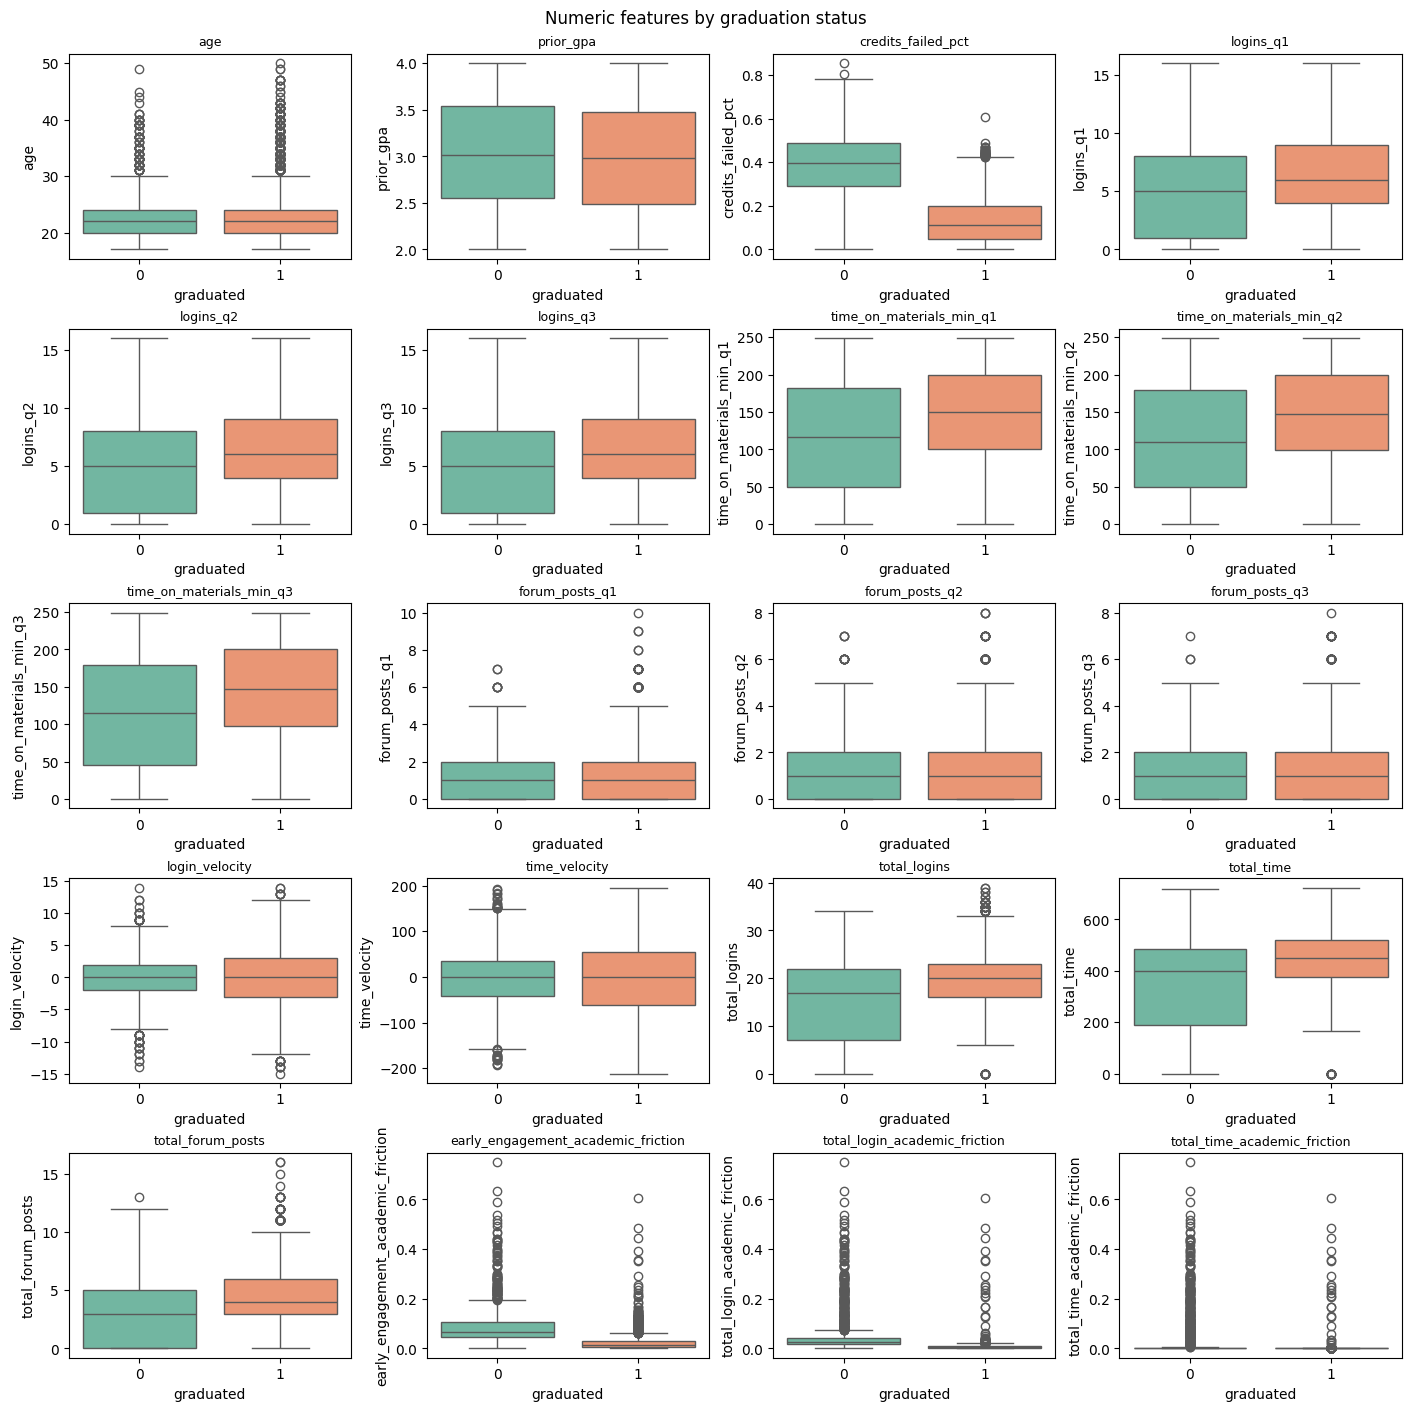

In [ ]:
# draw boxplot for all Numeric features by graduation status (exclude id + target)
# small overlap indicates a good predictor
exclude = {"student_id", "graduated", "is_ghost"}
num_cols = [
    c
    for c in df_master.select_dtypes(include=["number"]).columns
    if c not in exclude
]

n = len(num_cols)
ncols = 4
nrows = math.ceil(n / ncols) if n else 1

fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.5 * ncols, 2.8 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).ravel()

for idx, col in enumerate(num_cols):
    sns.boxplot(
        data=df_master,
        x="graduated",
        y=col,
        hue="graduated",
        palette="Set2",
        legend=False,
        ax=axes[idx],
    )
    axes[idx].set_title(col, fontsize=9)
    axes[idx].set_xlabel("graduated")
    axes[idx].tick_params(axis="x")

# Hide any unused subplot slots
for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Numeric features by graduation status", fontsize=12)
plt.show()

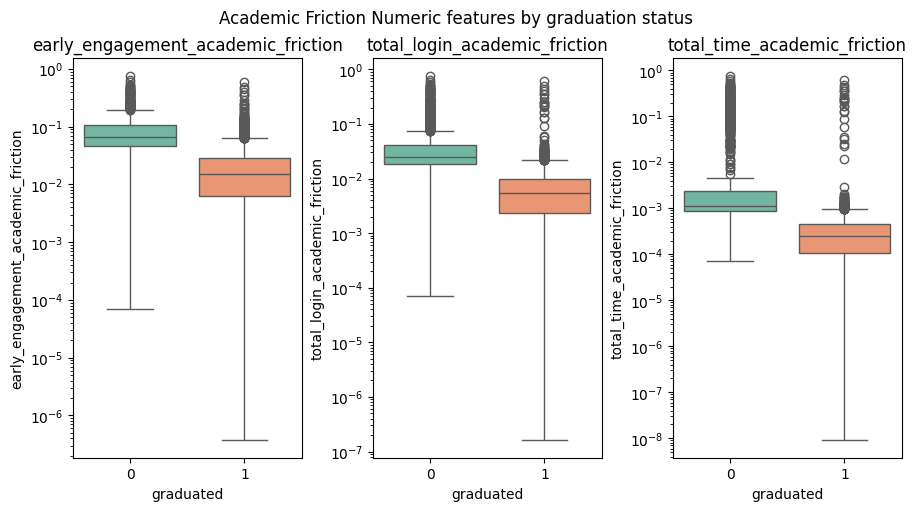

In [23]:
# Take a closer look at academic friction boxplots, use log scale to reduce cramming
num_cols = [
    "early_engagement_academic_friction",
    "total_login_academic_friction",
    "total_time_academic_friction",
]

fig, axes = plt.subplots(1, 3, figsize=(9, 5), constrained_layout=True)
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=df_master,
        x="graduated",
        y=col,
        hue="graduated",
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.set_title(col)
    ax.set_xlabel("graduated")
    ax.set_yscale("log")

fig.suptitle("Academic Friction Numeric features by graduation status", fontsize=12)
plt.show()

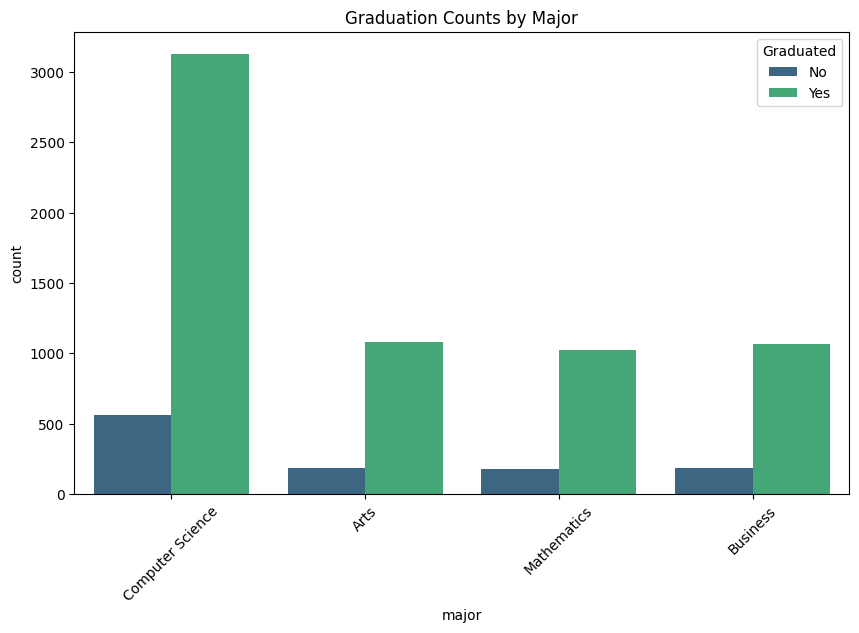

In [24]:
# Check relationship between Major and Graduation
plt.figure(figsize=(10, 6))
sns.countplot(data=df_master, x='major', hue='graduated', palette='viridis')
plt.title('Graduation Counts by Major')
plt.xticks(rotation=45)
plt.legend(title='Graduated', labels=['No', 'Yes'])
plt.show()

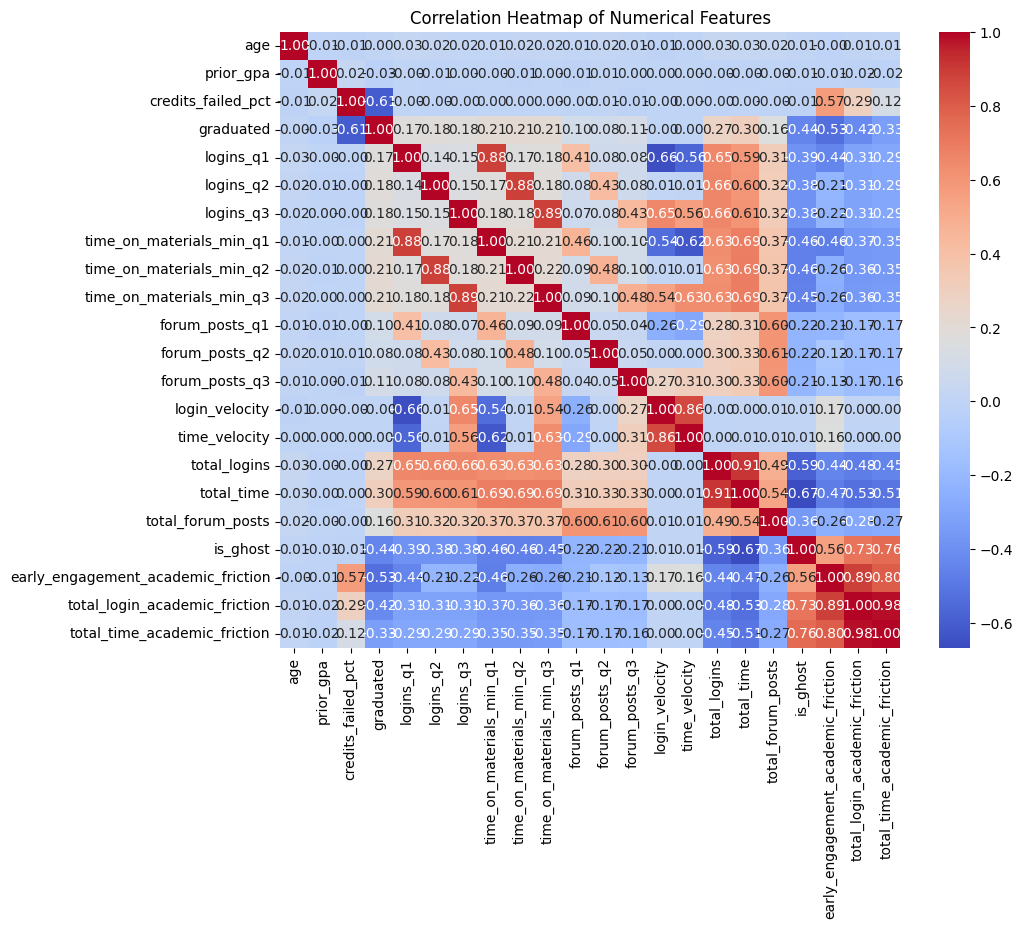

In [25]:
# Discover high and low correlations among numerical features
plt.figure(figsize=(10, 8))
correlation_matrix = df_master.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

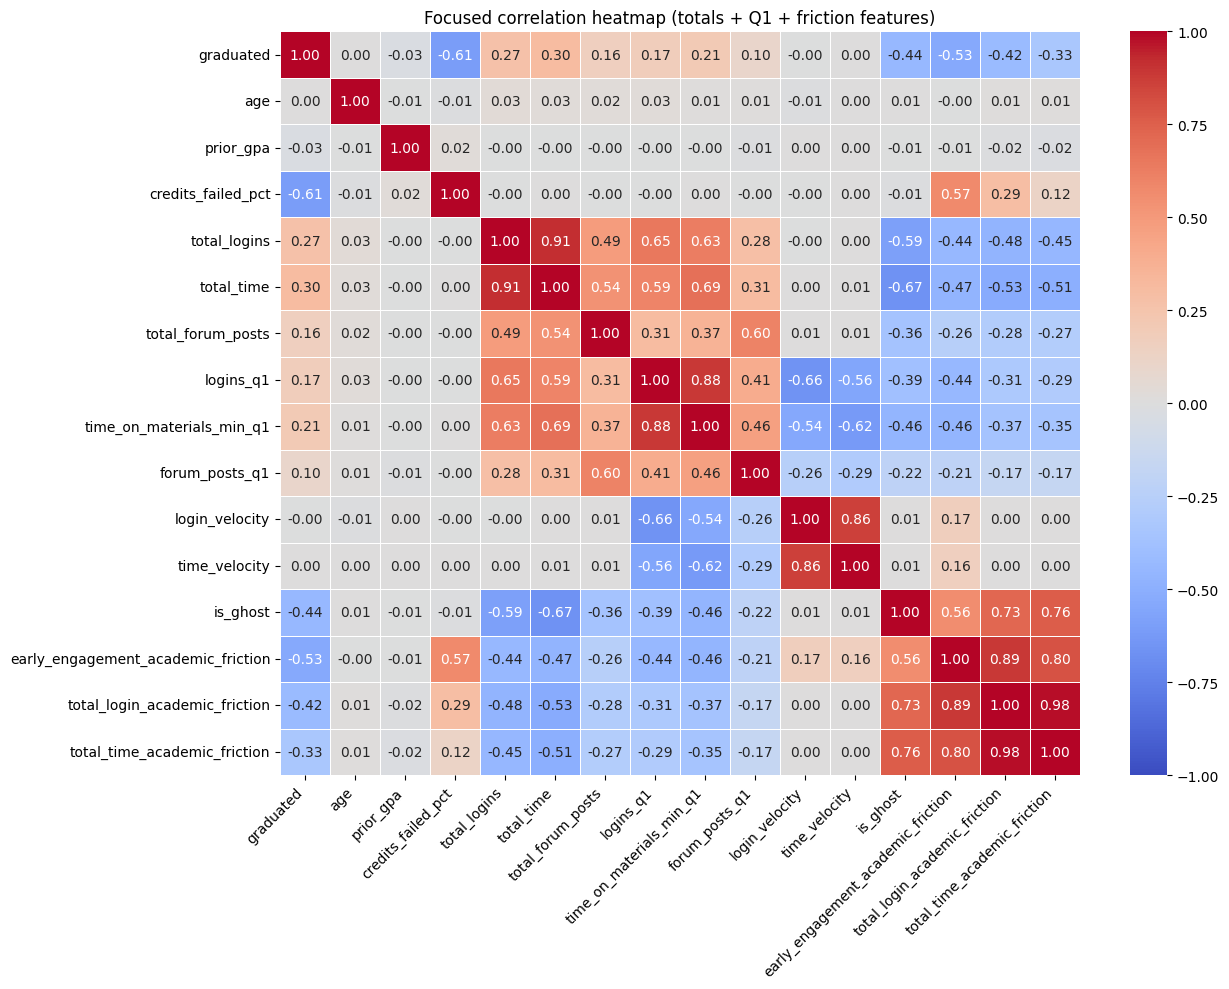

In [26]:
# Focused heat map, remove q2 and q3 variables for logins, time on materials, and forum posts.
keep_cols = [
    "graduated",
    "age",
    "prior_gpa",
    "credits_failed_pct",
    "total_logins",
    "total_time",
    "total_forum_posts",
    "logins_q1",
    "time_on_materials_min_q1",
    "forum_posts_q1",
    "login_velocity",
    "time_velocity",
    "is_ghost",
    "early_engagement_academic_friction",
    "total_login_academic_friction",
    "total_time_academic_friction",
]

keep_cols = [c for c in keep_cols if c in df_master.columns]
corr = df_master[keep_cols].corr(numeric_only=True)

plt.figure(figsize=(13, 10))
ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)
ax.set_title("Focused correlation heatmap (totals + Q1 + friction features)")

# rotate bottom (x-axis) labels
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

C:\Users\tbaug\AppData\Local\Temp\ipykernel_33692\2900006809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master, x='tuition_status', y='graduated', palette='magma')
C:\Users\tbaug\AppData\Local\Temp\ipykernel_33692\2900006809.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master, x='financial_aid', y='graduated', palette='viridis')


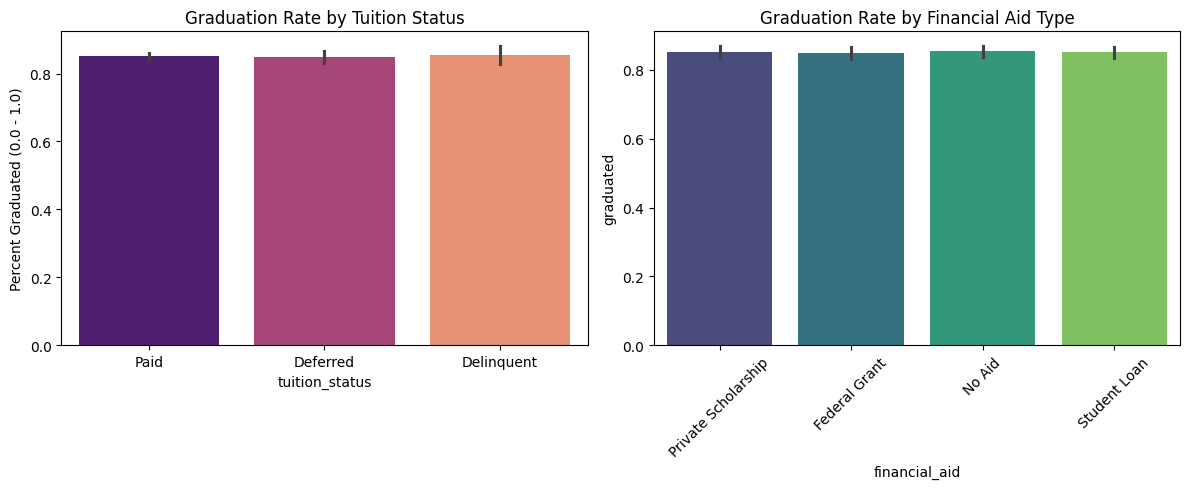

In [27]:
# View the graduation rates of various finance categories
 
plt.figure(figsize=(12, 5))

# Subplot 1: Tuition Status Impact
plt.subplot(1, 2, 1)
sns.barplot(data=df_master, x='tuition_status', y='graduated', palette='magma')
plt.title('Graduation Rate by Tuition Status')
plt.ylabel('Percent Graduated (0.0 - 1.0)')

# Subplot 2: Financial Aid Impact
plt.subplot(1, 2, 2)
sns.barplot(data=df_master, x='financial_aid', y='graduated', palette='viridis')
plt.title('Graduation Rate by Financial Aid Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### 'Ghost' Subgroup Analysis ####

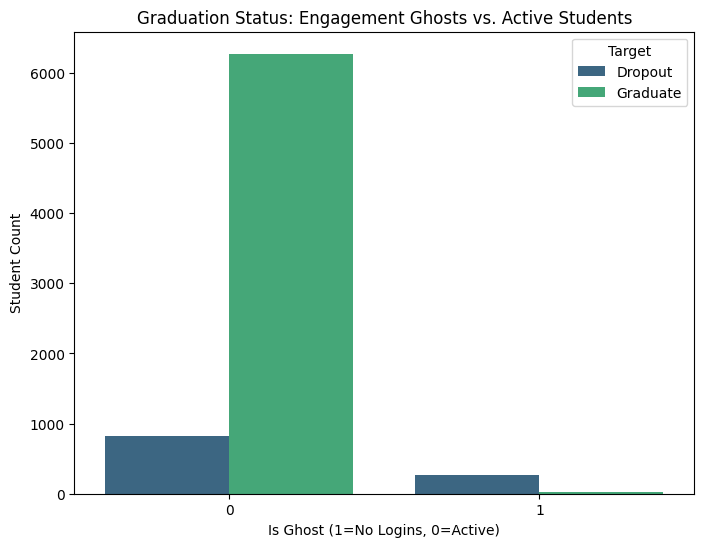

graduated,0,1,Total
is_ghost,,,
0,829,6272,7101
1,274,25,299
Total,1103,6297,7400


In [28]:
# Use countplot to see how many 'ghost' students graduate
plt.figure(figsize=(8, 6))
sns.countplot(data=df_master, x='is_ghost', hue='graduated', palette='viridis')
plt.title('Graduation Status: Engagement Ghosts vs. Active Students')
plt.xlabel('Is Ghost (1=No Logins, 0=Active)')
plt.ylabel('Student Count')
plt.legend(title='Target', labels=['Dropout', 'Graduate'])
plt.show()

# Same counts as a table (rows=is_ghost, cols=graduated; margins = row/col totals)
tbl_ghost_grad = pd.crosstab(
    df_master["is_ghost"],
    df_master["graduated"],
    margins=True,
    margins_name="Total",
)
display(tbl_ghost_grad)

In [29]:
cols = ["prior_gpa", "credits_failed_pct"]

summary = (
    df_master.groupby("is_ghost")[cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

for col in cols:
    print(f"\n{'=' * 60}\n{col} (by is_ghost)\n{'=' * 60}")
    print(summary[col])

# Check differences for statistical signicance with t-Test
# Split the data into ghosts and non-ghosts
ghosts = df_master[df_master['is_ghost'] == 1]
non_ghosts = df_master[df_master['is_ghost'] == 0]

cols = ["prior_gpa", "credits_failed_pct"]

for col in cols:
    # equal_var=False runs Welch's t-test (highly recommended for unequal sample sizes)
    t_stat, p_val = stats.ttest_ind(non_ghosts[col], ghosts[col], equal_var=False)
    print(f"\n{col}:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_val:.4f}")


prior_gpa (by is_ghost)
          count   mean  median    std  min   max
is_ghost                                        
0          7101  2.998    2.99  0.575  2.0  4.00
1           299  2.977    3.00  0.584  2.0  3.99

credits_failed_pct (by is_ghost)
          count   mean  median    std  min    max
is_ghost                                         
0          7101  0.169   0.132  0.144  0.0  0.854
1           299  0.159   0.118  0.134  0.0  0.750

prior_gpa:
  t-statistic: 0.5886
  p-value: 0.5565

credits_failed_pct:
  t-statistic: 1.2324
  p-value: 0.2187


Result: To determine if digital disengagement correlates with academic struggle, a subgroup analysis was conducted comparing "ghosts" (n = 299) against active students (n = 7101). Despite being digitally disengaged, "ghosts" look academically similar to non-ghosts across key metrics. The mean prior GPA for ghosts is 2.977 (Median = 3.00), closely mirroring non-ghosts at 2.998 (Median = 2.99). Furthermore, ghosts actually failed a slightly lower percentage of their credits on average (15.9%) compared to active students (16.9%). This suggests that digital disengagement in this dataset is not a direct proxy for academic failure. To mathematically validate these observations, an independent Welch's t-test was conducted on both metrics to account for the unequal group sizes. With P-values well above the standard .05 threshold, no statistically significant difference was found between the groups for either prior gpa or percentage of credits failed.